In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# XGB with True + Pseudo Labels (Full dataset)

In [28]:
df = pd.read_csv('TRUE_PSEUDO_featData.csv')

In [29]:
# Define features and target
descr = ['CoordinationNumber','PseudoLabelled','NumElementsSurface',
         'meanAtomicRadius','maxAtomicRadius','minAtomicRadius','stdAtomicRadius',	
         'meanAtomicMass','maxAtomicMass','minAtomicMass','stdAtomicMass',
         'meanAffinity','maxAffinity','minAffinity','stdAffinity',
         'meanDensity','maxDensity','minDensity','stdDensity',
         'meanGroup','maxGroup','minGroup','stdGroup',
         'meanMeltingP','maxMeltingP','minMeltingP','stdMeltingP',
         'meanIon','maxIon','minIon','stdIon',
         'meanElectronegativity','maxElectronegativity','minElectronegativity','stdElectronegativity',
         'meanPcount','maxPcount','minPcount','stdPcount',
         'meanDcount','maxDcount','minDcount','stdDcount',
]

target = 'ReactionEnergy'

# Prepare data
X = df[descr]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

'''# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)'''

xgb_model = XGBRegressor(objective='reg:squarederror',colsample_bytree= 0.8, learning_rate= 0.01, max_depth= 5, n_estimators= 400, subsample= 0.8, random_state=42)

from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

# Define 5-fold cross validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(xgb_model, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")

====== Cross-Validated Results ======
Mean Train R²:  0.9148 ± 0.0067
Mean Test  R²:  0.8153 ± 0.0146
Mean Test  MAE: 0.2128 ± 0.0107
Mean Test  RMSE:0.3072 ± 0.0166


In [30]:
# !pip install shap
import shap

In [ ]:
# Create a TreeExplainer for your XGB
xgb_model.fit(X_train, y_train)
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for all samples
shap_values = explainer.shap_values(X_train)  # For regression, returns a 2D array (samples x features)

# -------------------------------
# 1. Global Feature Importance
# -------------------------------
# This shows the mean absolute SHAP value per feature
shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=43, plot_size=(18,10))
plt.title("Global Feature Importance (SHAP)")
plt.show()

# -------------------------------
# 2. Summary Dot Plot
# -------------------------------
# Shows feature impact across all samples
shap.summary_plot(shap_values, X_train, plot_type="dot", max_display=15)

# -------------------------------
# 3. Dependence Plot for a single feature
# -------------------------------
# Example: plot SHAP value vs feature value for 'PseudoLabelled'
if 'meanGroup' in X.columns:
    shap.dependence_plot('meanGroup', shap_values, X_train)

# -------------------------------
# 4. Optional: Identify top contributing features for outliers
# -------------------------------
# Compute residuals
y_pred = xgb_model.predict(X_train)
residuals = y_test - y_pred

# Pick the top 10 largest absolute residuals
outlier_pos = residuals.abs().sort_values(ascending=False).head(10).index
outlier_pos = [residuals.index.get_loc(i) for i in outlier_pos] 




# XGB with True + Pseudo Labels (Top 10 features only)

In [31]:
descr = ['meanGroup','CoordinationNumber', 'meanDcount', 'meanMeltingP', 'minGroup', 'maxAtomicRadius','meanAtomicRadius',     
            'minDensity', 'meanElectronegativity']

target = "ReactionEnergy"

# Prepare data
X = df[descr]
y = df[target]

# Train-test split
X_train_top10, X_test_top10, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


'''# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0] }

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)'''

xgb_model_top10 = XGBRegressor(objective='reg:squarederror',colsample_bytree= 0.8, learning_rate= 0.01, max_depth= 5, n_estimators= 400, subsample= 0.8, random_state=42)

xgb_model_top10.fit(X_train_top10, y_train)

from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

# Define 5-fold cross validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(xgb_model_top10, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")


====== Cross-Validated Results ======
Mean Train R²:  0.8974 ± 0.0070
Mean Test  R²:  0.8143 ± 0.0148
Mean Test  MAE: 0.2125 ± 0.0099
Mean Test  RMSE:0.3080 ± 0.0173


# with Pseudo Labelled

====== Cross-Validated Results ======
Mean Train R²:  0.9064 ± 0.0059
Mean Test  R²:  0.8265 ± 0.0122
Mean Test  MAE: 0.2081 ± 0.0093
Mean Test  RMSE:0.2974 ± 0.0151


# XGB with True Labels ONLY

In [ ]:
df = pd.read_csv('true_ONLY_featureData.csv')

In [ ]:
# Define features and target
descr = ["CoordinationNumber", "NumElementsSurface", "ConfigEntropy_JmolK",
    "meanAtomicRadius", "maxAtomicRadius", "minAtomicRadius", "stdAtomicRadius",
    "meanAtomicMass", "maxAtomicMass", "minAtomicMass", "stdAtomicMass",
    "meanAffinity", "maxAffinity", "minAffinity", "stdAffinity",
    "meanDensity", "maxDensity", "minDensity", "stdDensity",
    "meanGroup", "maxGroup", "minGroup", "stdGroup",
    "meanMeltingP", "maxMeltingP", "minMeltingP", "stdMeltingP",
    "meanIon", "maxIon", "minIon", "stdIon",
    "meanElectronegativity", "maxElectronegativity", "minElectronegativity", "stdElectronegativity",
    "Facet_100", "Facet_101", "Facet_110", "Facet_111",
    "meanPcount", "maxPcount", "minPcount", "stdPcount",
    "meanDcount", "maxDcount", "minDcount", "stdDcount",
]

target = "ReactionEnergy"

# Prepare data
X = df[descr]
y = df[target]

'''# Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit model
grid_search.fit(X, y)

# Best model and parameters
xgb_model2 = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)'''

xgb_model2 = XGBRegressor(objective='reg:squarederror',colsample_bytree= 0.8, learning_rate= 0.01, max_depth= 5, n_estimators= 400, subsample= 0.8, random_state=42)

from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

# Define 5-fold cross validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(xgb_model2, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")


In [ ]:
# Create a TreeExplainer for your XGB model
explainer = shap.TreeExplainer(xgb_model_top10)

# Calculate SHAP values for all training samples
shap_values = explainer.shap_values(X_train)  # For regression, returns array (samples × features)

# -------------------------------
# 1. Compute Global Feature Importance (numerically)
# -------------------------------
# Get mean absolute SHAP value per feature
shap_importance = np.abs(shap_values).mean(axis=0)

# Combine feature names and importance values into a DataFrame
shap_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MeanAbsSHAP': shap_importance
}).sort_values(by='MeanAbsSHAP', ascending=False)

# Get the top 10 important features
top10_features = shap_importance_df.head(10)
print("\nTop 10 Important Features (by mean |SHAP|):")
print(top10_features)

# -------------------------------
# 2. SHAP Summary Plot (Global)
# -------------------------------
shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=47, plot_size=(18,10))
plt.title("Global Feature Importance (SHAP)")
plt.show()

# -------------------------------
# 3. Summary Dot Plot
# -------------------------------
shap.summary_plot(shap_values, X_train, plot_type="dot", max_display=15)

# -------------------------------
# 4. Dependence Plot for a Single Feature
# -------------------------------
if 'meanGroup' in X_train.columns:
    shap.dependence_plot('meanGroup', shap_values, X_train)

# -------------------------------
# 5. Identify Top Contributing Features for Outliers
# -------------------------------
y_pred = xgb_model2.predict(X_train)
residuals = y_train - y_pred

# Pick indices of the top 10 largest absolute residuals
outlier_idx = residuals.abs().nlargest(10).index
outlier_positions = [X_train.index.get_loc(i) for i in outlier_idx]

# SHAP force plot for these outliers
shap.force_plot(
    explainer.expected_value,
    shap_values[outlier_positions, :],
    X_train.iloc[outlier_positions, :]
)



# XGB with True Labels (top 10 features only)

In [ ]:
# Define features and target
descr = ['meanGroup','CoordinationNumber', 'meanDcount', 'meanMeltingP', 'minAtomicMass', 'maxAtomicRadius','meanAtomicRadius',     
            'meanAtomicMass', 'meanElectronegativity', 'meanAffinity',]

target = "ReactionEnergy"

# Prepare data
X = df[descr]
y = df[target]

# Train-test split
X_train_top10, X_test_top10, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


'''# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0] }

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train_top10, y_train)

# Best model and parameters
model2_top10 = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)'''


xgb_model2_top10 = XGBRegressor(objective='reg:squarederror',colsample_bytree= 0.8, learning_rate= 0.01, max_depth= 5, n_estimators= 400, subsample= 0.8, random_state=42)

from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

# Define 5-fold cross validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(xgb_model2_top10, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")

In [ ]:
# pip install scikit-optimize


In [32]:
from skopt import gp_minimize
from skopt.space import Integer
from math import gcd
from functools import reduce
from pymatgen.core import Composition

In [33]:
elementalProperty = pd.read_csv("PubChemElements_all.csv")

In [34]:
elementalProperty = elementalProperty.rename(columns = {'Group ' : 'Group'})
elementalProperty = elementalProperty.rename(columns = {'Outermost_d_count' : 'Dcount'})
elementalProperty = elementalProperty.rename(columns = {'Outermost_p_count' : 'Pcount'})
elementalProperty = elementalProperty.rename(columns = {'MeltingPoint' : 'MeltingP'})
elementalProperty = elementalProperty.rename(columns = {'ElectronAffinity' : 'Affinity'})
elementalProperty.columns

Index(['AtomicNumber', 'Symbol', 'Name', 'AtomicMass', 'CPKHexColor',
       'ElectronConfiguration', 'Electronegativity', 'AtomicRadius',
       'IonizationEnergy', 'Affinity', 'OxidationStates', 'StandardState',
       'MeltingP', 'BoilingPoint', 'Density', 'GroupBlock', 'YearDiscovered',
       'EnthalpyFusion', 'Pcount', 'Dcount', 'Group'],
      dtype='object')

In [35]:
def normalize_stoichiometry(composition):
    counts = [v for v in composition.values() if v > 0]
    if not counts:
        return composition
    g = reduce(gcd, counts)
    return {el: int(v // g) for el, v in composition.items() if v > 0}

In [36]:
import re
def elementalPropertyMapping_single(property_name, composition_str, elementalProperty):
    """
    Compute mean, max, min, std of a given elemental property for a single composition.
    """
    token = re.findall(r'([A-Z][a-z]?)(\d*)', composition_str)
    processed_token = [(el, int(num) if num else 1) for el, num in token]
    
    indiv_property = []
    indiv_atom = []
    totalAtom = 0
    
    for element, count in processed_token:
        totalAtom += count
        prop_val = elementalProperty[elementalProperty["Symbol"] == element][property_name].values[0]
        indiv_property.append(prop_val)
        indiv_atom.append(count)
    
    meanProperty = np.sum([p * (a / totalAtom) for p, a in zip(indiv_property, indiv_atom)])
    maxProperty = np.max(indiv_property)
    minProperty = np.min(indiv_property)
    stdProperty = np.sqrt(np.sum([(a / totalAtom) * (p - meanProperty) ** 2 for p, a in zip(indiv_property, indiv_atom)]))
    
    return [meanProperty, maxProperty, minProperty, stdProperty]


In [37]:
#Testing property mapping

desc = elementalPropertyMapping_single("Electronegativity", "Au3Bi", elementalProperty)
print(desc)

[2.41, 2.54, 2.02, 0.22516660498395405]


In [38]:
def compositionFeatureMapping_dynamic(comp_str,elementalProperty, feature_names):
    """
    Dynamically construct a feature vector for a single composition
    based on the trained model's expected feature names.
    """
    feature_vector = []

    # Precompute descriptors for all possible elemental properties
    cache = {}
    for f in feature_names:
        # Extract property name (everything after mean/max/min/std)
        match = re.match(r'(mean|max|min|std)([A-Z].*)', f)
        if match:
            stat, prop = match.groups()
            if prop not in cache:
                cache[prop] = {}
                mean_val, max_val, min_val, std_val = elementalPropertyMapping_single(prop, comp_str, elementalProperty)
                cache[prop]['mean'] = mean_val
                cache[prop]['max']  = max_val
                cache[prop]['min']  = min_val
                cache[prop]['std']  = std_val

    # Now fill the feature vector in the correct order
    for f in feature_names:
        match = re.match(r'(mean|max|min|std)([A-Z].*)', f)
        if match:
            stat, prop = match.groups()
            val = cache[prop][stat]
        else:
            # If the feature name doesn't follow mean/max/min/std pattern
            val = 0  # or handle custom features differently
        feature_vector.append(val)
    
    return np.array(feature_vector).reshape(1, -1)

In [50]:
try:
    X = compositionFeatureMapping_dynamic("AgO2", elementalProperty, xgb_model_top10.get_booster().feature_names)
    y_pred = xgb_model_top10.predict(X)[0]
    print(y_pred)
except Exception as e:
    print(f"Error mapping {comp_str}: {e}")
    y_pred = 10.0

1.4884603


In [40]:
def to_formula(comp):
    return ''.join(f"{el}{int(c) if c > 1 else ''}" for el, c in comp.items())

In [41]:
import numpy as np
import pandas as pd
import re
import itertools
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional
from functools import reduce
from math import gcd
from pymatgen.core.periodic_table import Element
# from pymatgen.core import Composition # Uncomment if using charge balance

# ----------------------------------------------------------------------
# Helper Functions
# ----------------------------------------------------------------------

def to_formula(comp: Dict[str, int]) -> str:
    """Convert a composition dict to a canonical formula string."""
    elements = sorted(comp.keys())
    formula = ""
    for el in elements:
        count = comp[el]
        formula += f"{el}{count if count > 1 else ''}"
    return formula

def normalize_stoichiometry(comp: Dict[str, int]) -> Dict[str, int]:
    """Normalize a composition to the smallest integer ratios."""
    counts = [count for count in comp.values() if count > 0]
    if not counts:
        return {}
    divisor = reduce(gcd, counts)
    return {el: count // divisor for el, count in comp.items() if count > 0}

# ----------------------------------------------------------------------
# Genetic Algorithm Class
# ----------------------------------------------------------------------

class MaterialInverseDesignGA:
    """Genetic Algorithm for inverse design of material compositions."""

    def __init__(self, 
                 model,
                 elemental_property_df: pd.DataFrame,
                 metal_elements: List[str],
                 target_value: float,
                 population_size: int = 100,
                 generations: int = 50,
                 max_atoms: int = 15,
                 mutation_rate: float = 0.2,
                 crossover_rate: float = 0.4,
                 elite_size: int = None,
                 elitism_rate: float = 0.05,
                 uncommon_state_penalty: float = 4.0,
                 charge_violation_penalty: float = 5.0,
                 random_injection_rate: float = 0.0,
                 hall_of_fame_size: int = 20,
                 fixed_unique_metal_count: Optional[int] = None,
                 metal_ratio_vector: Optional[List[float]] = None):
        self.model = model
        self.elemental_property = elemental_property_df
        self.allowed_elements = metal_elements
        self.target_value = target_value
        self.max_atoms = max(3, max_atoms)
        self.population_size = population_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.elitism_count = int(population_size * elitism_rate)
        self.uncommon_state_penalty = uncommon_state_penalty
        self.charge_violation_penalty = charge_violation_penalty
        self.random_injection_rate = max(0.0, min(random_injection_rate, 1.0))
        self.hall_of_fame_size = max(1, hall_of_fame_size)
        self._default_oxidation = 2

        if elite_size is not None:
            self.elite_size = elite_size
        else:
            self.elite_size = int(population_size * elitism_rate)

        self.oxygen_symbol = 'O' if 'O' in self.allowed_elements else None
        self.metal_pool = [el for el in self.allowed_elements if el != self.oxygen_symbol]
        if not self.metal_pool:
            self.metal_pool = self.allowed_elements.copy()

        self.feature_names = model.get_booster().feature_names

        self.history = {
            'best_fitness': [],
            'mean_fitness': [],
            'best_composition': [],
            'best_predicted': [],
            'best_CN': [],
            'population_unique': [],
            'evaluated_unique_so_far': []
        }

        self.evaluated_compositions_all = set()
        self.hall_of_fame_records: Dict[str, Dict[str, object]] = {}
        self._global_best_error = float('inf')
        self._global_best_generation = None
        self._global_best_formula = None
        self._global_best_cn = None

        self.fixed_unique_metal_count = None
        if fixed_unique_metal_count is not None:
            if fixed_unique_metal_count < 1:
                print("Warning: fixed_unique_metal_count must be >= 1; ignoring constraint.")
            else:
                self.fixed_unique_metal_count = fixed_unique_metal_count

        self.metal_ratio_vector = self._normalize_ratio_vector(
            metal_ratio_vector, self.fixed_unique_metal_count
        )
        self._element_count_penalty = 5.0
        self._stoichiometry_penalty_scale = 10.0

    def _normalize_ratio_vector(self, ratios: Optional[List[float]], expected_length: Optional[int]) -> Optional[List[float]]:
        if ratios is None or expected_length is None:
            return None
        if len(ratios) != expected_length:
            print("Warning: ratio vector length does not match requested element count; ignoring ratios.")
            return None
        try:
            values = [max(0.0, float(val)) for val in ratios]
        except (TypeError, ValueError):
            print("Warning: Unable to parse ratio vector; ignoring ratios.")
            return None
        total = sum(values)
        if total <= 0:
            print("Warning: Ratio vector sums to zero; ignoring ratios.")
            return None
        return [val / total for val in values]

    def _generate_counts_for_elements(self, elements: List[str], ratio_vector: Optional[List[float]], max_total_atoms: Optional[int] = None) -> Dict[str, int]:
        if not elements:
            return {}
        n = len(elements)
        if ratio_vector and len(ratio_vector) >= n:
            probs = np.array(ratio_vector[:n], dtype=float)
        else:
            probs = np.ones(n, dtype=float)
        probs_sum = probs.sum()
        if probs_sum <= 0:
            probs = np.ones(n, dtype=float)
            probs_sum = float(n)
        probs = probs / probs_sum
        total_cap = max_total_atoms if max_total_atoms is not None else self.max_atoms
        base_total = max(n, min(total_cap, n * 3))
        extra_cap = max(0, base_total - n)
        extra_atoms = np.random.randint(0, extra_cap + 1) if extra_cap > 0 else 0
        counts = np.ones(n, dtype=int)
        if extra_atoms > 0:
            allocation = np.random.multinomial(extra_atoms, probs)
            counts += allocation
        return {el: int(count) for el, count in zip(elements, counts)}

    # ------------------------------------------------------------------
# Oxidation-state utilities
# ----------------------------------------------------------------------
    def _get_oxidation_state_options(self, element_symbol: str) -> List[Dict[str, int]]:
        options: List[Dict[str, int]] = []
        try:
            element = Element(element_symbol)
        except Exception:
            print(f"Warning: Unable to load oxidation states for {element_symbol}; defaulting to +{self._default_oxidation}")
            return [{'state': self._default_oxidation, 'is_common': False, 'is_default': True}]

        common_states = sorted({int(oxi) for oxi in element.common_oxidation_states if int(oxi) > 0})
        all_states = sorted({int(oxi) for oxi in element.oxidation_states if int(oxi) > 0})
        extra_states = [state for state in all_states if state not in common_states]

        for state in common_states:
            options.append({'state': state, 'is_common': True, 'is_default': False})
        for state in extra_states:
            options.append({'state': state, 'is_common': False, 'is_default': False})

        if not options:
            print(f"Warning: No oxidation states found for {element_symbol}; defaulting to +{self._default_oxidation}")
            options.append({'state': self._default_oxidation, 'is_common': False, 'is_default': True})

        return options

    def _select_oxygen_count_for_metals(self, metal_counts: Dict[str, int]):
        if not self.oxygen_symbol:
            return metal_counts.copy()

        metals = list(metal_counts.keys())
        if not metals:
            return None

        options_per_metal = [self._get_oxidation_state_options(metal) for metal in metals]
        candidates = []

        for combo in itertools.product(*options_per_metal):
            total_positive = sum(metal_counts[metals[idx]] * combo[idx]['state'] for idx in range(len(metals)))
            if total_positive <= 0 or total_positive % 2 != 0:
                continue
            oxygen_count = total_positive // 2
            if oxygen_count <= 0:
                continue
            total_atoms = sum(metal_counts.values()) + oxygen_count
            if total_atoms > self.max_atoms:
                continue
            uses_common_only = all(option['is_common'] for option in combo)
            uses_default = any(option['is_default'] for option in combo)
            candidates.append({
                'oxygen_count': oxygen_count,
                'uses_common_only': uses_common_only,
                'uses_default': uses_default,
                'total_atoms': total_atoms
            })

        if not candidates:
            return None

        candidates.sort(key=lambda candidate: (
            candidate['total_atoms'] > self.max_atoms,
            not candidate['uses_common_only'],
            candidate['uses_default'],
            candidate['total_atoms'],
            candidate['oxygen_count']
        ))

        selected = candidates[0]
        composition = metal_counts.copy()
        composition[self.oxygen_symbol] = selected['oxygen_count']
        return composition

    def _assess_charge_neutrality(self, composition: Dict[str, int]) -> Dict[str, bool]:
        if not self.oxygen_symbol or self.oxygen_symbol not in composition:
            return {
                'is_neutral': False,
                'has_common_solution': False,
                'requires_uncommon': False,
                'uses_default': False
            }

        oxygen_count = composition.get(self.oxygen_symbol, 0)
        metal_counts = {el: count for el, count in composition.items() if el != self.oxygen_symbol and count > 0}
        if not metal_counts or oxygen_count <= 0:
            return {
                'is_neutral': False,
                'has_common_solution': False,
                'requires_uncommon': False,
                'uses_default': False
            }

        metals = list(metal_counts.keys())
        options_per_metal = [self._get_oxidation_state_options(metal) for metal in metals]
        neutral_combos = []
        for combo in itertools.product(*options_per_metal):
            total_positive = sum(metal_counts[metals[idx]] * combo[idx]['state'] for idx in range(len(metals)))
            if total_positive == oxygen_count * 2:
                neutral_combos.append(combo)

        if not neutral_combos:
            return {
                'is_neutral': False,
                'has_common_solution': False,
                'requires_uncommon': False,
                'uses_default': False
            }

        has_common_solution = any(all(option['is_common'] for option in combo) for combo in neutral_combos)
        uses_default = any(option['is_default'] for combo in neutral_combos for option in combo)
        return {
            'is_neutral': True,
            'has_common_solution': has_common_solution,
            'requires_uncommon': not has_common_solution,
            'uses_default': uses_default
        }

    # ------------------------------------------------------------------
# Feature mapping utilities
# ----------------------------------------------------------------------
    def elementalPropertyMapping_single(self, property_name: str, composition_str: str) -> List[float]:
        token = re.findall(r'([A-Z][a-z]?)(\d*)', composition_str)
        processed_token = [(el, int(num) if num else 1) for el, num in token]

        indiv_property = []
        indiv_atom = []
        totalAtom = 0

        for element, count in processed_token:
            totalAtom += count
            prop_row = self.elemental_property[self.elemental_property["Symbol"] == element]
            if prop_row.empty:
                raise ValueError(f"Property {property_name} for element {element} not found.")
            prop_val = prop_row[property_name].values[0]
            indiv_property.append(prop_val)
            indiv_atom.append(count)

        meanProperty = np.sum([p * (a / totalAtom) for p, a in zip(indiv_property, indiv_atom)])
        maxProperty = np.max(indiv_property)
        minProperty = np.min(indiv_property)
        stdProperty = np.sqrt(np.sum([
            (a / totalAtom) * (p - meanProperty) ** 2 for p, a in zip(indiv_property, indiv_atom)
        ]))

        return [meanProperty, maxProperty, minProperty, stdProperty]

    def compositionFeatureMapping(self, comp_str: str) -> np.ndarray:
        cache: Dict[str, Dict[str, float]] = {}
        feature_vector = []

        for f in self.feature_names:
            val = 0.0
            match = re.match(r'(mean|max|min|std)([A-Z].*)', f)

            if match:
                stat, prop = match.groups()
                if prop not in cache:
                    try:
                        mean_val, max_val, min_val, std_val = self.elementalPropertyMapping_single(prop, comp_str)
                        cache[prop] = {
                            'mean': mean_val,
                            'max': max_val,
                            'min': min_val,
                            'std': std_val
                        }
                    except Exception:
                        continue
                if prop in cache and stat in cache[prop]:
                    val = cache[prop][stat]

            elif f == 'CoordinationNumber':
                val = 0.0

            feature_vector.append(val)

        return np.array(feature_vector).reshape(1, -1)

    # ------------------------------------------------------------------
# Genetic operators
# ----------------------------------------------------------------------
    def create_random_composition(self) -> Dict[str, int]:
        if not self.allowed_elements:
            raise ValueError("No elements provided for composition generation.")

        element_pool = self.metal_pool if self.metal_pool else self.allowed_elements
        last_attempt = None
        for _ in range(7):
            if self.fixed_unique_metal_count is not None:
                n_metals = min(self.fixed_unique_metal_count, len(element_pool))
            else:
                n_metals = np.random.choice([1, 2], p=[0.6, 0.4])
                n_metals = min(n_metals, len(element_pool))
            metals = np.random.choice(element_pool, size=n_metals, replace=False)
            if self.metal_ratio_vector is not None and self.fixed_unique_metal_count is not None:
                ratio_vector = self.metal_ratio_vector
            else:
                ratio_vector = None
            metal_counts = self._generate_counts_for_elements(
                list(metals), ratio_vector,
                max_total_atoms=max(2, self.max_atoms - 2)
            )
            last_attempt = metal_counts
            balanced = self._select_oxygen_count_for_metals(metal_counts.copy())
            if balanced:
                return balanced

        composition = last_attempt.copy() if last_attempt else {}
        if not composition:
            fallback_element = np.random.choice(self.allowed_elements)
            composition[fallback_element] = 1
        if self.oxygen_symbol and self.oxygen_symbol not in composition:
            composition[self.oxygen_symbol] = np.random.randint(1, 4)
        return composition

    def normalize_composition(self, comp: Dict[str, int]) -> Dict[str, int]:
        return normalize_stoichiometry(comp)

    def evaluate_composition_all_CNs(self, composition_dict, target_value=None):
        if target_value is None:
            target_value = self.target_value
        comp_str = to_formula(composition_dict)
        results = []

        for CN in [1, 2, 3, 4]:
            try:
                X = self.compositionFeatureMapping(comp_str)
                try:
                    cn_idx = self.feature_names.index('CoordinationNumber')
                    X[0, cn_idx] = CN
                except ValueError:
                    print("Warning: 'CoordinationNumber' feature missing in model features.")
                    continue
                y_pred = self.model.predict(X)[0]
                error = abs(y_pred - target_value)
                results.append({
                    'formula': comp_str,
                    'CN': CN,
                    'predicted_energy': y_pred,
                    'error': error
                })
            except Exception:
                continue

        return results

    def composition_to_formula(self, comp: Dict[str, int]) -> str:
        return to_formula(comp)

    def predict_energy(self, comp: Dict[str, int]) -> float:
        try:
            comp_normalized = self.normalize_composition(comp)
            formula = self.composition_to_formula(comp_normalized)
            X = self.compositionFeatureMapping(formula)
            try:
                cn_idx = self.feature_names.index('CoordinationNumber')
                X[0, cn_idx] = 4.0
            except ValueError:
                pass
            prediction = self.model.predict(X)[0]
            return prediction
        except Exception:
            return np.nan

    def fitness(self, composition_dict):
        penalty = 0.0

        if len(composition_dict) < 2:
            penalty += 10.0
        if len(composition_dict) > 3:
            penalty += 5.0

        comp_normalized = normalize_stoichiometry(composition_dict)
        metals_only = [el for el in comp_normalized if el != self.oxygen_symbol]
        if self.fixed_unique_metal_count is not None:
            count_diff = abs(len(metals_only) - self.fixed_unique_metal_count)
            penalty += self._element_count_penalty * count_diff

        if self.metal_ratio_vector and metals_only and len(metals_only) == self.fixed_unique_metal_count:
            counts = np.array([comp_normalized[el] for el in metals_only], dtype=float)
            total = counts.sum()
            if total > 0:
                fractions = counts / total
                target = np.array(self.metal_ratio_vector[:len(metals_only)], dtype=float)
                target = target / target.sum()
                fractions_sorted = np.sort(fractions)
                target_sorted = np.sort(target)
                ratio_diff = np.abs(fractions_sorted - target_sorted).sum()
                penalty += self._stoichiometry_penalty_scale * ratio_diff

        charge_meta = self._assess_charge_neutrality(comp_normalized)
        if not charge_meta['is_neutral']:
            penalty += self.charge_violation_penalty
        elif charge_meta['requires_uncommon'] or charge_meta['uses_default']:
            penalty += self.uncommon_state_penalty

        if sum(comp_normalized.values()) > self.max_atoms:
            penalty += 3.0

        cn_results = self.evaluate_composition_all_CNs(comp_normalized, self.target_value)
        if not cn_results:
            return -1000.0

        best_result = min(cn_results, key=lambda x: x['error'])
        return -(best_result['error'] + penalty)

    def mutate(self, comp: Dict[str, int]) -> Dict[str, int]:
        comp_new = comp.copy()
        mutation_type = np.random.random()

        elements_in_comp = list(comp_new.keys())
        if not elements_in_comp:
            new_el = np.random.choice(self.allowed_elements)
            comp_new[new_el] = 1
            return comp_new

        non_oxygen_elements = [el for el in elements_in_comp if el != 'O']
        fixed_count = self.fixed_unique_metal_count

        if mutation_type < 0.35:
            target_elements = non_oxygen_elements if non_oxygen_elements else elements_in_comp
            element = np.random.choice(target_elements)
            delta = np.random.choice([-2, -1, 1, 2])
            comp_new[element] = max(1, comp_new[element] + delta)

        elif mutation_type < 0.75:
            if fixed_count is None:
                if len(elements_in_comp) < 4:
                    available = [m for m in self.allowed_elements if m not in elements_in_comp]
                    if available:
                        new_element = np.random.choice(available)
                        comp_new[new_element] = np.random.randint(1, 4)
                elif len(elements_in_comp) > 1:
                    target_elements = non_oxygen_elements if non_oxygen_elements and len(non_oxygen_elements) > 1 else elements_in_comp
                    element_to_remove = np.random.choice(target_elements)
                    del comp_new[element_to_remove]
            else:
                available = [m for m in self.allowed_elements if m not in elements_in_comp]
                if available and non_oxygen_elements:
                    element_to_replace = np.random.choice(non_oxygen_elements)
                    new_element = np.random.choice(available)
                    comp_new[new_element] = comp_new[element_to_replace]
                    del comp_new[element_to_replace]

        else:
            available = [m for m in self.allowed_elements if m not in elements_in_comp]
            if available and elements_in_comp:
                target_elements = non_oxygen_elements if non_oxygen_elements else elements_in_comp
                old_element = np.random.choice(target_elements)
                new_element = np.random.choice(available)
                comp_new[new_element] = comp_new[old_element]
                del comp_new[old_element]

        return comp_new

    def crossover(self, parent1: Dict[str, int], parent2: Dict[str, int]) -> Dict[str, int]:
        all_elements = set(parent1.keys()) | set(parent2.keys())
        child = {}

        for element in all_elements:
            count1 = parent1.get(element, 0)
            count2 = parent2.get(element, 0)

            if count1 > 0 and count2 > 0:
                child[element] = parent1[element] if np.random.random() < 0.5 else parent2[element]

            elif count1 > 0:
                if np.random.random() < 0.7:
                    child[element] = count1
            elif count2 > 0:
                if np.random.random() < 0.7:
                    child[element] = count2

        if not child:
            return self.create_random_composition()

        if np.random.random() < 0.1:
            elements_in_child = list(child.keys())
            available_to_swap = [m for m in self.allowed_elements if m not in elements_in_child]
            if elements_in_child and available_to_swap:
                old_element = np.random.choice(elements_in_child)
                new_element = np.random.choice(available_to_swap)
                child[new_element] = child[old_element]
                del child[old_element]

        return child

    def _update_hall_of_fame(self, formula: str, composition: Dict[str, int], error: float, predicted: float, cn: int, generation: int):
        record = self.hall_of_fame_records.get(formula)
        if (record is None) or (error < record['error'] - 1e-12):
            self.hall_of_fame_records[formula] = {
                'formula': formula,
                'composition': dict(composition),
                'error': error,
                'predicted': predicted,
                'CN': cn,
                'generation': generation
            }
        if len(self.hall_of_fame_records) > self.hall_of_fame_size:
            worst_formula = max(self.hall_of_fame_records.items(), key=lambda item: item[1]['error'])[0]
            del self.hall_of_fame_records[worst_formula]

    def get_hall_of_fame_entries(self) -> List[Dict[str, object]]:
        return sorted(self.hall_of_fame_records.values(), key=lambda entry: entry['error'])

    # ------------------------------------------------------------------
# Evolution loop
# ----------------------------------------------------------------------
    def evolve(self, verbose: bool = True, verbose_interval: int = 10):
        population = [self.create_random_composition() for _ in range(self.population_size)]
        last_verbose_gen = None

        for gen in range(self.generations):
            fitness_scores = []
            generation_unique = set()

            for comp in population:
                normalized = self.normalize_composition(comp)
                comp_key = tuple(sorted(normalized.items()))
                self.evaluated_compositions_all.add(comp_key)
                generation_unique.add(comp_key)
                fitness_scores.append(self.fitness(comp))

            self.history['population_unique'].append(len(generation_unique))
            self.history['evaluated_unique_so_far'].append(len(self.evaluated_compositions_all))

            best_idx = np.argmax(fitness_scores)
            best_comp = population[best_idx]
            best_predicted = self.predict_energy(best_comp)

            normalized_best = self.normalize_composition(best_comp)
            cn_results = self.evaluate_composition_all_CNs(normalized_best, self.target_value)
            if cn_results:
                best_result = min(cn_results, key=lambda x: x['error'])
                best_predicted = best_result['predicted_energy']
                best_error = best_result['error']
                best_cn = best_result['CN']
            else:
                best_error = 1000.0
                best_cn = None

            improved = best_error < (self._global_best_error - 1e-9)
            if improved:
                self._global_best_error = best_error
                self._global_best_generation = gen
                self._global_best_formula = self.composition_to_formula(normalized_best)
                self._global_best_cn = best_cn

            self._update_hall_of_fame(self.composition_to_formula(normalized_best), normalized_best, best_error, best_predicted, best_cn, gen)

            self.history['best_fitness'].append(best_error)
            self.history['mean_fitness'].append(-np.mean(fitness_scores))
            self.history['best_composition'].append(self.composition_to_formula(normalized_best))
            self.history['best_predicted'].append(best_predicted)
            self.history['best_CN'].append(best_cn)

            should_print = (gen % verbose_interval == 0) or (gen == self.generations - 1) or improved
            if verbose and should_print and gen != last_verbose_gen:
                formula = self.composition_to_formula(normalized_best)
                cn_str = f" | CN: {best_cn}" if best_cn is not None else ""
                print(f"Gen {gen:3d} | Best: {formula:15s} | Predicted: {best_predicted:.3f} eV | Error: {best_error:.3f} eV{cn_str}")
                last_verbose_gen = gen

            selected = []
            for _ in range(self.population_size - self.elitism_count):
                tournament = np.random.choice(self.population_size, size=3, replace=False)
                winner_idx = tournament[np.argmax([fitness_scores[i] for i in tournament])]
                selected.append(population[winner_idx])

            elite_indices = np.argsort(fitness_scores)[-self.elitism_count:]
            elite = [population[i] for i in elite_indices]

            new_population = elite.copy()
            for i in range(0, len(selected) - 1, 2):
                parent1, parent2 = selected[i], selected[i + 1]
                if np.random.random() < self.crossover_rate:
                    child1 = self.crossover(parent1, parent2)
                    child2 = self.crossover(parent2, parent1)
                else:
                    child1, child2 = parent1.copy(), parent2.copy()
                if np.random.random() < self.mutation_rate:
                    child1 = self.mutate(child1)
                if np.random.random() < self.mutation_rate:
                    child2 = self.mutate(child2)
                new_population.extend([child1, child2])

            if self.random_injection_rate > 0.0:
                immigrants = max(1, int(self.population_size * self.random_injection_rate))
                for _ in range(immigrants):
                    if len(new_population) >= self.population_size:
                        break
                    new_population.append(self.create_random_composition())

            while len(new_population) < self.population_size:
                new_population.append(self.create_random_composition())

            population = new_population[:self.population_size]

        return population, fitness_scores

    # ------------------------------------------------------------------
# Reporting utilities
# ----------------------------------------------------------------------

    def get_best_candidates(self, n_top: int = 10) -> pd.DataFrame:
        unique_comps = {}
        for gen in range(len(self.history['best_composition'])):
            formula = self.history['best_composition'][gen]
            pred = self.history['best_predicted'][gen]
            error = self.history['best_fitness'][gen]
            cn = self.history['best_CN'][gen]
            if formula not in unique_comps or error < unique_comps[formula]['error']:
                unique_comps[formula] = {'predicted': pred, 'error': error, 'CN': cn}

        sorted_comps = sorted(unique_comps.items(), key=lambda x: x[1]['error'])[:n_top]
        results = []
        for formula, data in sorted_comps:
            results.append({
                'Formula': formula,
                'Predicted_Energy': data['predicted'],
                'Error_from_Target': data['error'],
                'Best_CN': data['CN'],
                'Target': self.target_value
            })
        return pd.DataFrame(results)

    def plot_convergence(self, show: bool = True, save_path: Optional[str] = None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        ax1.plot(self.history['best_fitness'], 'b-', linewidth=2, label='Best')
        ax1.plot(self.history['mean_fitness'], 'r--', alpha=0.6, label='Mean')
        #ax1.axhline(y=0.2125, color='g', linestyle=':', label='Model MAE')
        ax1.set_xlabel('Generation')
        ax1.set_ylabel('Fitness (eV)')
        ax1.set_title('Convergence Curve')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2.plot(self.history['best_predicted'], 'b-', linewidth=2)
        ax2.axhline(y=self.target_value, color='r', linestyle='--', label=f'Target: {self.target_value} eV')
        # ax2.fill_between(range(len(self.history['best_predicted'])),
        #                  self.target_value - 0.2125,
        #                  self.target_value + 0.2125,
        #                  alpha=0.2, color='green', label='±1 MAE')
        ax2.set_xlabel('Generation')
        ax2.set_ylabel('Predicted Energy (eV)')
        y_min = min(min(self.history['best_predicted']), self.target_value)
        y_max = max(max(self.history['best_predicted']), self.target_value)
        pad = 0.0005
        ax2.set_ylim(y_min - pad, y_max + pad)      
        ax2.set_title('Best Predicted Energy vs Target')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches='tight')
        if show:
            plt.show()
        else:
            plt.close(fig)
        return fig

# end of class MaterialInverseDesignGA

In [42]:
class MetallicMaterialInverseDesignGA(MaterialInverseDesignGA):
    """Metal-only variant of the inverse-design GA."""
    def __init__(self,
                 model,
                 elemental_property_df: pd.DataFrame,
                 metal_elements: List[str],
                 target_value: float,
                 **kwargs):
        metallic_only = [el for el in metal_elements if Element(el).is_metal]
        if not metallic_only:
            raise ValueError("No metallic elements supplied for MetallicMaterialInverseDesignGA.")
        super().__init__(model=model,
                         elemental_property_df=elemental_property_df,
                         metal_elements=metallic_only,
                         target_value=target_value,
                         **kwargs)
        self.allowed_elements = metallic_only
        self.metal_pool = metallic_only
        self.oxygen_symbol = None

    def _select_oxygen_count_for_metals(self, metal_counts: Dict[str, int]):
        return {el: count for el, count in metal_counts.items() if count > 0}

    def _assess_charge_neutrality(self, composition: Dict[str, int]) -> Dict[str, bool]:
        return {
            'is_neutral': True,
            'has_common_solution': True,
            'requires_uncommon': False,
            'uses_default': False
        }

    def mutate(self, comp: Dict[str, int]) -> Dict[str, int]:
        comp_new = comp.copy()
        mutation_type = np.random.random()

        elements_in_comp = list(comp_new.keys())
        if not elements_in_comp:
            new_el = np.random.choice(self.allowed_elements)
            comp_new[new_el] = 1
            return comp_new

        fixed_count = self.fixed_unique_metal_count

        if mutation_type < 0.2: 
            element = np.random.choice(elements_in_comp)
            delta = np.random.choice([-2, -1, 1, 2])
            comp_new[element] = max(1, comp_new[element] + delta)

        elif mutation_type < 0.65:
            if fixed_count is None:
                available = [m for m in self.allowed_elements if m not in elements_in_comp]
                if available and len(elements_in_comp) < 4:
                    new_element = np.random.choice(available)
                    comp_new[new_element] = np.random.randint(1, 4)
                elif len(elements_in_comp) > 1:
                    element_to_remove = np.random.choice(elements_in_comp)
                    del comp_new[element_to_remove]
            else:
                available = [m for m in self.allowed_elements if m not in elements_in_comp]
                if available and elements_in_comp:
                    element_to_replace = np.random.choice(elements_in_comp)
                    new_element = np.random.choice(available)
                    comp_new[new_element] = comp_new[element_to_replace]
                    del comp_new[element_to_replace]

        else:
            available = [m for m in self.allowed_elements if m not in elements_in_comp]
            if available and elements_in_comp:
                old_element = np.random.choice(elements_in_comp)
                new_element = np.random.choice(available)
                comp_new[new_element] = comp_new[old_element]
                del comp_new[old_element]

        return comp_new

    def crossover(self, parent1: Dict[str, int], parent2: Dict[str, int]) -> Dict[str, int]:
        all_elements = set(parent1.keys()) | set(parent2.keys())
        child = {}

        for element in all_elements:
            count1 = parent1.get(element, 0)
            count2 = parent2.get(element, 0)

            if count1 > 0 and count2 > 0:
                child[element] = parent1[element] if np.random.random() < 0.5 else parent2[element]
            elif count1 > 0:
                if np.random.random() < 0.7:
                    child[element] = count1
            elif count2 > 0:
                if np.random.random() < 0.7:
                    child[element] = count2

        if not child:
            return self.create_random_composition()

        if np.random.random() < 0.1:
            elements_in_child = list(child.keys())
            available_to_swap = [m for m in self.allowed_elements if m not in elements_in_child]
            if elements_in_child and available_to_swap:
                old_element = np.random.choice(elements_in_child)
                new_element = np.random.choice(available_to_swap)
                child[new_element] = child[old_element]
                del child[old_element]

        return child

In [43]:
def get_top_n_unique_compositions(results_df, n=10):
    """Get top N unique compositions with their best CN"""
    unique_compositions = []
    seen_formulas = set()
    
    for _, row in results_df.iterrows():
        formula = row['formula']
        if formula not in seen_formulas:
            seen_formulas.add(formula)
            unique_compositions.append(row)
            if len(unique_compositions) >= n:
                break
    
    return pd.DataFrame(unique_compositions)

In [44]:
# ==============================================================================
# USAGE EXAMPLE
# ==============================================================================

# Initialize the GA optimizer
ga_optimizer = MaterialInverseDesignGA(
    model=xgb_model_top10,
    elemental_property_df=elementalProperty,
    metal_elements=['O',  'Se', 'Te',
                     'Cu', 'Zn', 'Zr', 'Nb', 'Mo', 'Tc', 'Rh', 'Pd',
                     'Cr', 'Mn', 'Fe', 'Co', 'Ni','Ru', 'Ag', 'Au', 'Ca', 'La', 'Ce',
                     'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Ir', 'Pt', 'Mg', 'Li', 'Ca', 'Sc', 'Ti'],
    target_value=1.2,
    population_size=800,
    generations=50,
    elite_size=2,
    mutation_rate=0.3,
    crossover_rate=0.7,
    max_atoms=20,
    random_injection_rate=0.2
)

# Run the GA
print("Starting Genetic Algorithm Optimization...")
print("=" * 60)
final_population, final_fitness = ga_optimizer.evolve(verbose=True)

print("\n" + "="*70)
print("DEBUG: History Values")
print("="*70)
print(f"First 10 best_fitness values: {ga_optimizer.history['best_fitness'][:10]}")
print(f"Last 10 best_fitness values: {ga_optimizer.history['best_fitness'][-10:]}")
print(f"Min fitness: {min(ga_optimizer.history['best_fitness'])}")
print(f"Max fitness: {max(ga_optimizer.history['best_fitness'])}")
if ga_optimizer.history['evaluated_unique_so_far']:
    print(f"Unique compositions screened (cumulative): {ga_optimizer.history['evaluated_unique_so_far'][-1]}")
print("="*70)

# Get best candidates
print("\n" + "=" * 60)
print("OPTIMIZATION COMPLETE")
print("=" * 60)

final_results = []
seen_compositions = set()  # Track unique normalized compositions

for comp_dict in final_population:
    normalized_comp = ga_optimizer.normalize_composition(comp_dict)
    comp_str = ga_optimizer.composition_to_formula(normalized_comp)

    if comp_str in seen_compositions:
        continue
    seen_compositions.add(comp_str)

    cn_results = ga_optimizer.evaluate_composition_all_CNs(normalized_comp)
    for result in cn_results:
        result['formula'] = comp_str
    final_results.extend(cn_results)

hall_of_fame_entries = ga_optimizer.get_hall_of_fame_entries()
for entry in hall_of_fame_entries:
    comp_dict = entry['composition']
    comp_str = entry['formula']
    cn_results = ga_optimizer.evaluate_composition_all_CNs(comp_dict)
    for result in cn_results:
        result['formula'] = comp_str
    final_results.extend(cn_results)

results_df = pd.DataFrame(final_results)

if results_df.empty:
    raise ValueError("No valid candidates were generated.")

results_df = results_df.drop_duplicates(subset=['formula', 'CN'])
results_df = results_df.sort_values('error').reset_index(drop=True)

print("\n" + "="*70)
print("TOP 20 CANDIDATES (NON-REPEATING COMPOSITIONS)")
print("="*70)
print(f"{'Rank':<6}{'Formula':<15}{'CN':<6}{'Predicted (eV)':<18}{'Error (eV)':<12}")
print("-"*70)

for idx, row in results_df.head(20).iterrows():
    print(f"{idx+1:<6}{row['formula']:<15}{row['CN']:<6}{row['predicted_energy']:<18.4f}{row['error']:<12.4f}")

print("="*70)

top_unique = get_top_n_unique_compositions(results_df, n=10)

print("\n" + "="*70)
print("TOP 10 UNIQUE COMPOSITIONS (BEST COORDINATION NUMBER)")
print("="*70)
print(f"{'Rank':<6}{'Formula':<15}{'Best CN':<10}{'Predicted (eV)':<18}{'Error (eV)':<12}")
print("-"*70)

for idx, row in top_unique.iterrows():
    print(f"{idx+1:<6}{row['formula']:<15}{row['CN']:<10}{row['predicted_energy']:<18.4f}{row['error']:<12.4f}")

print("="*70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Best fitness over generations
generations = list(range(len(ga_optimizer.history['best_fitness'])))
ax1.plot(generations, ga_optimizer.history['best_fitness'], 
         marker='o', linewidth=2, markersize=4, color='#2E86AB')
ax1.axhline(y=0, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Target (0 error)')
ax1.set_xlabel('Generation', fontsize=12)
ax1.set_ylabel('Best Error (eV)', fontsize=12)
ax1.set_title('Optimization Learning Curve\n(Lower is Better)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Best vs Mean fitness
ax2.plot(generations, ga_optimizer.history['best_fitness'], 
         marker='o', linewidth=2, markersize=4, color='#2E86AB', label='Best')
ax2.plot(generations, ga_optimizer.history['mean_fitness'], 
         marker='s', linewidth=2, markersize=4, color='#A23B72', alpha=0.7, label='Mean')
ax2.axhline(y=0, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Target')
ax2.set_xlabel('Generation', fontsize=12)
ax2.set_ylabel('Error (eV)', fontsize=12)
ax2.set_title('Population Fitness Evolution', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# ============================================================================
# Summary Statistics
# ============================================================================
history_unique = len(set(ga_optimizer.history['best_composition']))
final_unique = results_df['formula'].nunique()
final_unique_pop = len(seen_compositions)
total_unique_screened = len(ga_optimizer.evaluated_compositions_all)
latest_generation_unique = ga_optimizer.history['population_unique'][-1] if ga_optimizer.history['population_unique'] else 0
mean_unique_per_generation = np.mean(ga_optimizer.history['population_unique']) if ga_optimizer.history['population_unique'] else 0
hall_of_fame_size = len(hall_of_fame_entries)
best_hof_entry = hall_of_fame_entries[0] if hall_of_fame_entries else None

print("\n" + "="*70)
print("OPTIMIZATION SUMMARY")
print("="*70)
print(f"Target Energy:                               {ga_optimizer.target_value} eV")
print(f"Best Error Achieved:                         {results_df['error'].min():.4f} eV")
print(f"Best Composition:                            {results_df.iloc[0]['formula']}")
print(f"Best Coordination Number:                    {results_df.iloc[0]['CN']}")
print(f"Predicted Energy:                            {results_df.iloc[0]['predicted_energy']:.4f} eV")
print(f"Unique Compositions Screened (cumulative):   {total_unique_screened}")
print(f"Unique Compositions (final CN sweep):        {final_unique}")
print(f"Unique Compositions (final population):      {final_unique_pop}")
print(f"Unique Best-so-far Compositions:             {history_unique}")
print(f"Avg unique per generation:                   {mean_unique_per_generation:.2f}")
print(f"Latest generation unique (normalized):       {latest_generation_unique}")
print(f"Hall-of-Fame entries retained:               {hall_of_fame_size}")
if best_hof_entry is not None:
    print(f"Hall-of-Fame best composition:               {best_hof_entry['formula']} (error {best_hof_entry['error']:.4f} eV, gen {best_hof_entry['generation']})")
if ga_optimizer._global_best_generation is not None:
    print(f"Best candidate first observed at generation: {ga_optimizer._global_best_generation}")
    print(f"Best candidate composition:                  {ga_optimizer._global_best_formula}")
    print(f"Best candidate CN:                           {ga_optimizer._global_best_cn}")
print(f"Final Generation Best:                       {ga_optimizer.history['best_composition'][-1]}")
print(f"Final Generation CN:                         {ga_optimizer.history['best_CN'][-1]}")
print("="*70)

Starting Genetic Algorithm Optimization...
Gen   0 | Best: O6PrTb3         | Predicted: 1.200 eV | Error: 0.000 eV | CN: 1
Gen   0 | Best: O6PrTb3         | Predicted: 1.200 eV | Error: 0.000 eV | CN: 1


KeyboardInterrupt: 

In [ ]:
print(['meanGroup','CoordinationNumber', 'meanDcount', 'meanMeltingP', 'minGroup', 'maxAtomicRadius','meanAtomicRadius',     
            'minDensity', 'meanElectronegativity'])
feature_names = xgb_model_top10.get_booster().feature_names
comp_str = "RuO15"
features = compositionFeatureMapping_dynamic(comp_str, elementalProperty, feature_names)
print("Features for RuO15:", features)

# Compare to a normal oxide
comp_str_normal = "RuO2"
features_normal = compositionFeatureMapping_dynamic(comp_str_normal, elementalProperty, feature_names)
print("Features for RuO2:", features_normal)

In [ ]:
# def plot_convergence(self, show: bool = True, save_path: Optional[str] = None):
#     if not self.history['best_fitness'] or not self.history['best_predicted']:
#         print("No convergence data available; run evolve() first.")
#         return None
#     generations = np.arange(len(self.history['best_fitness']))
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
#     best_predicted = np.array(self.history['best_predicted'], dtype=float)
#     target_line = float(self.target_value) if self.target_value is not None else 0.0
#     mae_band = 0.2125
#     ax1.plot(generations, best_predicted,
#                  marker='o', linewidth=2, markersize=4, color='#2E86AB', label='Best predicted')
#     ax1.axhline(y=target_line, color='r', linestyle='--', linewidth=1.2, label=f'Target: {target_line:.3f} eV')
#     ax1.fill_between(generations,
#                          target_line - mae_band,
#                          target_line + mae_band,
#                          alpha=0.15, color='green', label='±1 MAE')
#     ax1.set_xlabel('Generation')
#     ax1.set_ylabel('Predicted Energy (eV)')
#     ax1.set_title('Best Predicted Energy vs Target')
#     ax1.grid(True, alpha=0.3)
#     ax1.legend()
#     best_errors = np.array(self.history['best_fitness'], dtype=float)
#     mean_errors = np.array(self.history['mean_fitness'], dtype=float) if self.history['mean_fitness'] else np.full_like(best_errors, np.nan)
#     ax2.plot(generations, best_errors,
#                  marker='o', linewidth=2, markersize=4, color='#2E86AB', label='Best')
#     ax2.plot(generations, mean_errors,
#                  marker='s', linewidth=2, markersize=4, color='#A23B72', alpha=0.7, label='Mean')
#     ax2.axhline(y=0, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Target')
#     ax2.set_xlabel('Generation')
#     ax2.set_ylabel('Error (eV)')
#     ax2.set_title('Population Fitness Evolution')
#     ax2.grid(True, alpha=0.3)
#     ax2.legend()
#     plt.tight_layout()
#     if save_path:
#        fig.savefig(save_path, dpi=300, bbox_inches='tight')
#     if show:
#         plt.show()
#     else:
#         plt.close(fig)
#     return fig

In [45]:
# ==============================================================================
# USAGE EXAMPLE
# ==============================================================================

# Initialize the GA optimizer
ga_optimizer = MetallicMaterialInverseDesignGA(
    model=xgb_model_top10,
    elemental_property_df=elementalProperty,
    metal_elements=['Se', 'Te',
                     'Cu', 'Zn', 'Zr', 'Nb', 'Mo', 'Tc', 'Rh', 'Pd',
                     'Cr', 'Mn', 'Fe', 'Co', 'Ni','Ru', 'Ag', 'Au', 'Ca', 'La', 'Ce',
                     'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Ir', 'Pt', 'Mg', 'Li', 'Ca', 'Sc', 'Ti'],
    target_value=1.2,
    population_size=800,
    generations=50,
    elite_size=2,
    mutation_rate=0.3,
    crossover_rate=0.7,
    max_atoms=20,
    random_injection_rate=0.2
)

# Run the GA
print("Starting Genetic Algorithm Optimization...")
print("=" * 60)
final_population, final_fitness = ga_optimizer.evolve(verbose=True)

print("\n" + "="*70)
print("DEBUG: History Values")
print("="*70)
print(f"First 10 best_fitness values: {ga_optimizer.history['best_fitness'][:10]}")
print(f"Last 10 best_fitness values: {ga_optimizer.history['best_fitness'][-10:]}")
print(f"Min fitness: {min(ga_optimizer.history['best_fitness'])}")
print(f"Max fitness: {max(ga_optimizer.history['best_fitness'])}")
if ga_optimizer.history['evaluated_unique_so_far']:
    print(f"Unique compositions screened (cumulative): {ga_optimizer.history['evaluated_unique_so_far'][-1]}")
print("="*70)

# Get best candidates
print("\n" + "=" * 60)
print("OPTIMIZATION COMPLETE")
print("=" * 60)

final_results = []
seen_compositions = set()  # Track unique normalized compositions

for comp_dict in final_population:
    normalized_comp = ga_optimizer.normalize_composition(comp_dict)
    comp_str = ga_optimizer.composition_to_formula(normalized_comp)

    if comp_str in seen_compositions:
        continue
    seen_compositions.add(comp_str)

    cn_results = ga_optimizer.evaluate_composition_all_CNs(normalized_comp)
    for result in cn_results:
        result['formula'] = comp_str
    final_results.extend(cn_results)

hall_of_fame_entries = ga_optimizer.get_hall_of_fame_entries()
for entry in hall_of_fame_entries:
    comp_dict = entry['composition']
    comp_str = entry['formula']
    cn_results = ga_optimizer.evaluate_composition_all_CNs(comp_dict)
    for result in cn_results:
        result['formula'] = comp_str
    final_results.extend(cn_results)

results_df = pd.DataFrame(final_results)

if results_df.empty:
    raise ValueError("No valid candidates were generated.")

results_df = results_df.drop_duplicates(subset=['formula', 'CN'])
results_df = results_df.sort_values('error').reset_index(drop=True)

print("\n" + "="*70)
print("TOP 20 CANDIDATES (NON-REPEATING COMPOSITIONS)")
print("="*70)
print(f"{'Rank':<6}{'Formula':<15}{'CN':<6}{'Predicted (eV)':<18}{'Error (eV)':<12}")
print("-"*70)

for idx, row in results_df.head(20).iterrows():
    print(f"{idx+1:<6}{row['formula']:<15}{row['CN']:<6}{row['predicted_energy']:<18.4f}{row['error']:<12.4f}")

print("="*70)

top_unique = get_top_n_unique_compositions(results_df, n=10)

print("\n" + "="*70)
print("TOP 10 UNIQUE COMPOSITIONS (BEST COORDINATION NUMBER)")
print("="*70)
print(f"{'Rank':<6}{'Formula':<15}{'Best CN':<10}{'Predicted (eV)':<18}{'Error (eV)':<12}")
print("-"*70)

for idx, row in top_unique.iterrows():
    print(f"{idx+1:<6}{row['formula']:<15}{row['CN']:<10}{row['predicted_energy']:<18.4f}{row['error']:<12.4f}")

print("="*70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Best fitness over generations
generations = list(range(len(ga_optimizer.history['best_fitness'])))
ax1.plot(generations, ga_optimizer.history['best_fitness'], 
         marker='o', linewidth=2, markersize=4, color='#2E86AB')
ax1.axhline(y=0, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Target (0 error)')
ax1.set_xlabel('Generation', fontsize=12)
ax1.set_ylabel('Best Error (eV)', fontsize=12)
ax1.set_title('Optimization Learning Curve\n(Lower is Better)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Best vs Mean fitness
ax2.plot(generations, ga_optimizer.history['best_fitness'], 
         marker='o', linewidth=2, markersize=4, color='#2E86AB', label='Best')
ax2.plot(generations, ga_optimizer.history['mean_fitness'], 
         marker='s', linewidth=2, markersize=4, color='#A23B72', alpha=0.7, label='Mean')
ax2.axhline(y=0, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Target')
ax2.set_xlabel('Generation', fontsize=12)
ax2.set_ylabel('Error (eV)', fontsize=12)
ax2.set_title('Population Fitness Evolution', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# ============================================================================
# Summary Statistics
# ============================================================================
history_unique = len(set(ga_optimizer.history['best_composition']))
final_unique = results_df['formula'].nunique()
final_unique_pop = len(seen_compositions)
total_unique_screened = len(ga_optimizer.evaluated_compositions_all)
latest_generation_unique = ga_optimizer.history['population_unique'][-1] if ga_optimizer.history['population_unique'] else 0
mean_unique_per_generation = np.mean(ga_optimizer.history['population_unique']) if ga_optimizer.history['population_unique'] else 0
hall_of_fame_size = len(hall_of_fame_entries)
best_hof_entry = hall_of_fame_entries[0] if hall_of_fame_entries else None

print("\n" + "="*70)
print("OPTIMIZATION SUMMARY")
print("="*70)
print(f"Target Energy:                               {ga_optimizer.target_value} eV")
print(f"Best Error Achieved:                         {results_df['error'].min():.4f} eV")
print(f"Best Composition:                            {results_df.iloc[0]['formula']}")
print(f"Best Coordination Number:                    {results_df.iloc[0]['CN']}")
print(f"Predicted Energy:                            {results_df.iloc[0]['predicted_energy']:.4f} eV")
print(f"Unique Compositions Screened (cumulative):   {total_unique_screened}")
print(f"Unique Compositions (final CN sweep):        {final_unique}")
print(f"Unique Compositions (final population):      {final_unique_pop}")
print(f"Unique Best-so-far Compositions:             {history_unique}")
print(f"Avg unique per generation:                   {mean_unique_per_generation:.2f}")
print(f"Latest generation unique (normalized):       {latest_generation_unique}")
print(f"Hall-of-Fame entries retained:               {hall_of_fame_size}")
if best_hof_entry is not None:
    print(f"Hall-of-Fame best composition:               {best_hof_entry['formula']} (error {best_hof_entry['error']:.4f} eV, gen {best_hof_entry['generation']})")
if ga_optimizer._global_best_generation is not None:
    print(f"Best candidate first observed at generation: {ga_optimizer._global_best_generation}")
    print(f"Best candidate composition:                  {ga_optimizer._global_best_formula}")
    print(f"Best candidate CN:                           {ga_optimizer._global_best_cn}")
print(f"Final Generation Best:                       {ga_optimizer.history['best_composition'][-1]}")
print(f"Final Generation CN:                         {ga_optimizer.history['best_CN'][-1]}")
print("="*70)

Starting Genetic Algorithm Optimization...
Gen   0 | Best: Ag3Rh           | Predicted: 1.208 eV | Error: 0.008 eV | CN: 1
Gen   0 | Best: Ag3Rh           | Predicted: 1.208 eV | Error: 0.008 eV | CN: 1


KeyboardInterrupt: 


=== Inverse Design GA Interface ===
Select system type:
  1) Oxide-focused (charge balanced)
  2) Metallic (no oxygen handling)

Select element pool option:
  1) Use default element list
  2) Enter custom elements (comma-separated)

Select element pool option:
  1) Use default element list
  2) Enter custom elements (comma-separated)

Would you like to constrain the number of unique elements per composition?

Would you like to constrain the number of unique elements per composition?

Configured parameters:
  System type: metallic
  Elements: Li, Be, Na, Mg, Al, K, Ca, Sc, Ti, V, Cr, Mn, Fe, Co, Ni, Cu, Zn, Rb, Sr, Y, Zr, Nb, Mo, Tc, Ru, Rh, Pd, Ag, Cd, Cs, Ba, Hf, Ta, W, Re, Os, Ir, Pt, Au, Hg
  Population size: 800
  Generations: 20

Starting Genetic Algorithm Optimization...

Configured parameters:
  System type: metallic
  Elements: Li, Be, Na, Mg, Al, K, Ca, Sc, Ti, V, Cr, Mn, Fe, Co, Ni, Cu, Zn, Rb, Sr, Y, Zr, Nb, Mo, Tc, Ru, Rh, Pd, Ag, Cd, Cs, Ba, Hf, Ta, W, Re, Os, Ir, Pt, Au,

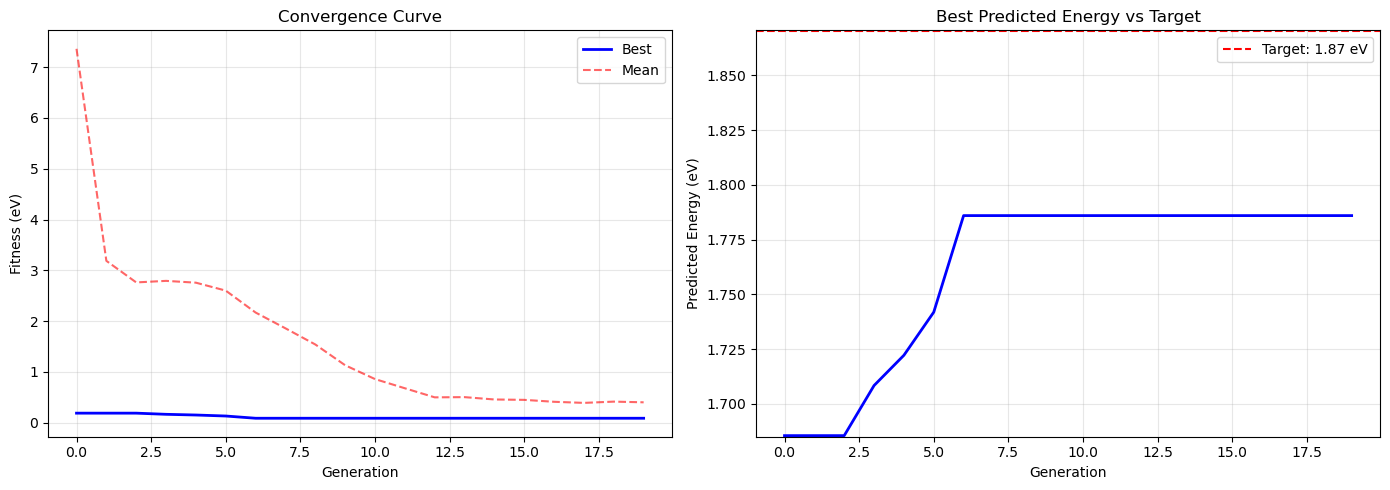


Save results?
  1) Save top 20 candidates
  2) Save convergence plot
  3) Save full results table
  4) Save all (top 20, full table, plot)
  5) Save none
No files saved.
No files saved.


(<__main__.MetallicMaterialInverseDesignGA at 0x33dfa54c0>,
       formula  CN  predicted_energy     error
 0       AgAu3   1          1.785940  0.084060
 1       AgAu5   1          1.781977  0.088023
 2       AgAu4   1          1.781301  0.088699
 3       AgAu2   1          1.741874  0.128126
 4      Ag2Au3   1          1.733341  0.136659
 ..        ...  ..               ...       ...
 611     CaZr3   3         -0.738661  2.608661
 612  AgCs3Li2   3         -0.756152  2.626152
 613     AgTa3   4         -0.765154  2.635154
 614     AgBa3   3         -0.769454  2.639454
 615     AgTa3   3         -0.840522  2.710522
 
 [616 rows x 4 columns])

In [47]:
from pathlib import Path
from typing import List, Optional, Tuple
def _parse_element_list(raw_text: str) -> List[str]:
    tokens = [token.strip() for token in raw_text.split(',')]
    cleaned = []
    for token in tokens:
        if not token:
            continue
        token = token.strip()
        if len(token) == 1:
            cleaned.append(token.upper())
        else:
            cleaned.append(token[0].upper() + token[1:].lower())
    return list(dict.fromkeys(cleaned))
def _prompt_element_pool(default_elements: List[str], require_oxygen: bool = False) -> List[str]:
    print("\nSelect element pool option:")
    print("  1) Use default element list")
    print("  2) Enter custom elements (comma-separated)")
    choice = input("Enter choice [1/2] (default=1): ").strip() or '1'
    if choice == '2':
        custom_text = input("Enter element symbols separated by commas (e.g., Fe, Co, Cr): ").strip()
        custom_elements = _parse_element_list(custom_text)
        if not custom_elements:
            print("No valid elements detected; falling back to default list.")
            selected = default_elements
        else:
            selected = custom_elements
    else:
        selected = default_elements
    selected = [el for el in selected if el]
    if require_oxygen and 'O' not in selected:
        print("Adding O to satisfy oxide search space.")
        selected.append('O')
    if not require_oxygen:
        selected = [el for el in selected if el != 'O']
    if not selected:
        raise ValueError("Element pool cannot be empty.")
    return list(dict.fromkeys(selected))
def _prompt_positive_int(prompt: str, default: int, min_value: int = 1) -> int:
    raw = input(f"{prompt} [{default}]: ").strip()
    if not raw:
        return default
    try:
        value = int(raw)
        if value < min_value:
            raise ValueError
        return value
    except ValueError:
        print(f"Invalid integer provided; using default value {default}.")
        return default
def _prompt_float_list(prompt: str, expected_length: int) -> Optional[List[float]]:
    raw = input(prompt).strip()
    if not raw:
        return None
    parts = [part.strip() for part in raw.split(',')]
    if len(parts) != expected_length:
        print("Provided percentages do not match the requested element count; using equal weights.")
        return None
    values = []
    for part in parts:
        try:
            values.append(float(part))
        except ValueError:
            print("Invalid numeric value detected; using equal weights.")
            return None
    total = sum(values)
    if total <= 0:
        print("Percentages sum to zero; using equal weights.")
        return None
    normalized = [val / total for val in values]
    return normalized
def _prompt_custom_composition_preferences(system_label: str) -> Tuple[Optional[int], Optional[List[float]]]:
    print("\nWould you like to constrain the number of unique elements per composition?")
    choice = input("Enter 'y' to configure, anything else to skip: ").strip().lower()
    if choice not in {'y', 'yes'}:
        return None, None
    max_allowed = 4 if system_label == 'oxide' else 5
    fixed_count = _prompt_positive_int(
        f"Enter the number of unique {('metal ' if system_label == 'oxide' else '')}elements per composition",
        default=2,
        min_value=1
    )
    if fixed_count > max_allowed:
        print(f"Limiting element count to {max_allowed} for stability.")
        fixed_count = max_allowed
    ratio_prompt = (
        f"Enter target percentages for the {fixed_count} elements (comma-separated, e.g., 60,40).\n"
        "Leave blank for uniform distribution: "
    )
    ratio_vector = _prompt_float_list(ratio_prompt, fixed_count)
    if ratio_vector is None:
        ratio_vector = [1.0 / fixed_count] * fixed_count
    return fixed_count, ratio_vector
def _summarize_ga_run(ga_optimizer, final_population, final_fitness) -> Tuple[pd.DataFrame, pd.DataFrame]:
    final_results = []
    seen_compositions = set()
    for comp_dict in final_population:
        normalized_comp = ga_optimizer.normalize_composition(comp_dict)
        comp_str = ga_optimizer.composition_to_formula(normalized_comp)
        if comp_str in seen_compositions:
            continue
        seen_compositions.add(comp_str)
        cn_results = ga_optimizer.evaluate_composition_all_CNs(normalized_comp)
        for result in cn_results:
            result['formula'] = comp_str
        final_results.extend(cn_results)
    hall_entries = ga_optimizer.get_hall_of_fame_entries()
    for entry in hall_entries:
        comp_dict = entry['composition']
        comp_str = entry['formula']
        cn_results = ga_optimizer.evaluate_composition_all_CNs(comp_dict)
        for result in cn_results:
            result['formula'] = comp_str
        final_results.extend(cn_results)
    results_df = pd.DataFrame(final_results)
    if results_df.empty:
        raise ValueError("No valid candidates were generated.")
    results_df = results_df.drop_duplicates(subset=['formula', 'CN']).sort_values('error').reset_index(drop=True)
    print("\n" + "="*70)
    print("TOP 20 CANDIDATES (NON-REPEATING COMPOSITIONS)")
    print("="*70)
    print(f"{'Rank':<6}{'Formula':<15}{'CN':<6}{'Predicted (eV)':<18}{'Error (eV)':<12}")
    print("-"*70)
    for idx, row in results_df.head(20).iterrows():
        print(f"{idx+1:<6}{row['formula']:<15}{row['CN']:<6}{row['predicted_energy']:<18.4f}{row['error']:<12.4f}")
    print("="*70)
    if 'get_top_n_unique_compositions' in globals():
        top_unique = get_top_n_unique_compositions(results_df, n=10)
    else:
        top_unique = results_df.sort_values('error').drop_duplicates('formula').head(10)
    print("\n" + "="*70)
    print("TOP 10 UNIQUE COMPOSITIONS (BEST COORDINATION NUMBER)")
    print("="*70)
    print(f"{'Rank':<6}{'Formula':<15}{'Best CN':<10}{'Predicted (eV)':<18}{'Error (eV)':<12}")
    print("-"*70)
    for idx, row in top_unique.iterrows():
        print(f"{idx+1:<6}{row['formula']:<15}{row['CN']:<10}{row['predicted_energy']:<18.4f}{row['error']:<12.4f}")
    print("="*70)
    history_unique = len(set(ga_optimizer.history['best_composition']))
    final_unique = results_df['formula'].nunique()
    final_unique_pop = len(seen_compositions)
    total_unique_screened = len(ga_optimizer.evaluated_compositions_all)
    latest_generation_unique = ga_optimizer.history['population_unique'][-1] if ga_optimizer.history['population_unique'] else 0
    mean_unique_per_generation = np.mean(ga_optimizer.history['population_unique']) if ga_optimizer.history['population_unique'] else 0
    hall_of_fame_size = len(hall_entries)
    best_hof_entry = hall_entries[0] if hall_entries else None
    print("\n" + "="*70)
    print("OPTIMIZATION SUMMARY")
    print("="*70)
    print(f"Target Energy:                               {ga_optimizer.target_value} eV")
    print(f"Best Error Achieved:                         {results_df['error'].min():.4f} eV")
    print(f"Best Composition:                            {results_df.iloc[0]['formula']}")
    print(f"Best Coordination Number:                    {results_df.iloc[0]['CN']}")
    print(f"Predicted Energy:                            {results_df.iloc[0]['predicted_energy']:.4f} eV")
    print(f"Unique Compositions Screened (cumulative):   {total_unique_screened}")
    print(f"Unique Compositions (final CN sweep):        {final_unique}")
    print(f"Unique Compositions (final population):      {final_unique_pop}")
    print(f"Unique Best-so-far Compositions:             {history_unique}")
    print(f"Avg unique per generation:                   {mean_unique_per_generation:.2f}")
    print(f"Latest generation unique (normalized):       {latest_generation_unique}")
    print(f"Hall-of-Fame entries retained:               {hall_of_fame_size}")
    if best_hof_entry is not None:
        print(f"Hall-of-Fame best composition:               {best_hof_entry['formula']} (error {best_hof_entry['error']:.4f} eV, gen {best_hof_entry['generation']})")
    if getattr(ga_optimizer, '_global_best_generation', None) is not None:
        print(f"Best candidate first observed at generation: {ga_optimizer._global_best_generation}")
        print(f"Best candidate composition:                  {ga_optimizer._global_best_formula}")
        print(f"Best candidate CN:                           {ga_optimizer._global_best_cn}")
    if ga_optimizer.history['best_composition']:
        print(f"Final Generation Best:                       {ga_optimizer.history['best_composition'][-1]}")
        print(f"Final Generation CN:                         {ga_optimizer.history['best_CN'][-1]}")
    print("="*70)
    return results_df, top_unique
def _prompt_save_outputs(results_df: pd.DataFrame, top20_df: pd.DataFrame, ga_optimizer):
    print("\nSave results?")
    print("  1) Save top 20 candidates")
    print("  2) Save convergence plot")
    print("  3) Save full results table")
    print("  4) Save all (top 20, full table, plot)")
    print("  5) Save none")
    choice = input("Enter choice [1-5] (default=5): ").strip() or '5'
    if choice not in {'1', '2', '3', '4', '5'}:
        print("Invalid choice; skipping save operations.")
        return
    if choice == '5':
        print("No files saved.")
        return
    def _save_dataframe(df: pd.DataFrame, default_name: str):
        filename = input(f"Enter filename for {default_name} (.csv or .xlsx): ").strip()
        if not filename:
            filename = default_name
        path = Path(filename)
        if path.suffix.lower() not in {'.csv', '.xlsx'}:
            path = path.with_suffix('.csv')
        if path.suffix.lower() == '.csv':
            df.to_csv(path, index=False)
        else:
            df.to_excel(path, index=False)
        print(f"Saved table to {path.resolve()}")
    def _save_plot(default_name: str):
        filename = input(f"Enter filename for convergence plot (.png/.pdf/.svg) [{default_name}]: ").strip()
        if not filename:
            filename = default_name
        path = Path(filename)
        if path.suffix.lower() not in {'.png', '.pdf', '.svg'}:
            path = path.with_suffix('.png')
        ga_optimizer.plot_convergence(show=False, save_path=str(path))
        print(f"Saved plot to {path.resolve()}")
    if choice in {'1', '4'}:
        _save_dataframe(top20_df, 'top20_candidates.csv')
    if choice in {'3', '4'}:
        _save_dataframe(results_df, 'ga_results.csv')
    if choice in {'2', '4'}:
        _save_plot('convergence.png')
def run_inverse_design_interface():
    oxide_default_elements = [
        "Li", "Be", "Na", 
        "Mg", "Al", "K", "Ca", "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn",
        "Rb", "Sr", "Y", "Zr", "Nb", "Mo", "Tc", "Ru", "Rh", "Pd", "Ag", "Cd",
        "Cs", "Ba", 
        "Hf", "Ta", "W", "Re", "Os", "Ir", "Pt", "Au", "Hg", 

    ]
    metallic_default_elements = [el for el in oxide_default_elements if el != 'O']
    print("\n=== Inverse Design GA Interface ===")
    print("Select system type:")
    print("  1) Oxide-focused (charge balanced)")
    print("  2) Metallic (no oxygen handling)")
    system_choice = input("Enter choice [1/2] (default=2): ").strip() or '2'
    if system_choice not in {'1', '2'}:
        print("Invalid choice; defaulting to metallic search.")
        system_choice = '2'
    if system_choice == '1':
        GAClass = MaterialInverseDesignGA
        default_elements = oxide_default_elements
        element_list = _prompt_element_pool(default_elements, require_oxygen=True)
        system_label = 'oxide'
        extra_kwargs = {
            'uncommon_state_penalty': 4.0,
            'charge_violation_penalty': 5.0
        }
    else:
        GAClass = MetallicMaterialInverseDesignGA
        default_elements = metallic_default_elements
        element_list = _prompt_element_pool(default_elements, require_oxygen=False)
        system_label = 'metallic'
        extra_kwargs = {}
    fixed_count, ratio_vector = _prompt_custom_composition_preferences(system_label)
    population_size = _prompt_positive_int("Enter population size", default=800, min_value=10)
    generations = _prompt_positive_int("Enter number of generations", default=50, min_value=1)
    mutation_rate = 0.3
    crossover_rate = 0.7
    random_injection_rate = 0.2
    print("\nConfigured parameters:")
    print(f"  System type: {system_label}")
    print(f"  Elements: {', '.join(element_list)}")
    print(f"  Population size: {population_size}")
    print(f"  Generations: {generations}")
    # print(f"  Mutation rate: {mutation_rate}")
    # print(f"  Crossover rate: {crossover_rate}")
    # print(f"  Random injection rate: {random_injection_rate}")
    if fixed_count is not None:
        print(f"  Target unique elements per composition: {fixed_count}")
        if ratio_vector:
            ratio_display = ', '.join(f"{val*100:.1f}%" for val in ratio_vector)
            print(f"  Initial proportion template: {ratio_display}")
    ga_kwargs = {
        'model': xgb_model_top10,
        'elemental_property_df': elementalProperty,
        'metal_elements': element_list,
        'target_value': 1.87,
        'population_size': population_size,
        'generations': generations,
        'elite_size': 2,
        'mutation_rate': mutation_rate,
        'crossover_rate': crossover_rate,
        'max_atoms': 20,
        'random_injection_rate': random_injection_rate
    }
    if fixed_count is not None:
        if system_choice == '1':
            ga_kwargs['fixed_unique_metal_count'] = fixed_count
            ga_kwargs['metal_ratio_vector'] = ratio_vector
        else:
            ga_kwargs['fixed_unique_element_count'] = fixed_count
            ga_kwargs['element_ratio_vector'] = ratio_vector
    ga_kwargs.update(extra_kwargs)
    ga_optimizer = GAClass(**ga_kwargs)
    print("\nStarting Genetic Algorithm Optimization...")
    print("=" * 60)
    final_population, final_fitness = ga_optimizer.evolve(verbose=True)
    results_df, top_unique = _summarize_ga_run(ga_optimizer, final_population, final_fitness)
    try:
        ga_optimizer.plot_convergence(show=True)
    except Exception as exc:
        print(f"Plotting skipped: {exc}")
    top20_df = results_df.head(20).copy()
    _prompt_save_outputs(results_df, top20_df, ga_optimizer)
    return ga_optimizer, results_df
run_inverse_design_interface()

# Inverse Design GA Interface (restored)


This interface prompts for GA settings, element pool, and mode (oxide vs metallic), then runs the GA with per-generation progress and prints a summary of top candidates.

In [ ]:
# # Helper prompts for the GA interface (restored)
# from typing import List

# def _prompt_choice(prompt: str, options: List[str], default_index: int = 0) -> int:
#     opts_str = "\n".join([f"  {i+1}) {opt}" for i, opt in enumerate(options)])
#     while True:
#         raw = input(f"{prompt}\n{opts_str}\nEnter choice [default {default_index+1}]: ").strip()
#         if raw == "":
#             return default_index
#         if raw.isdigit():
#             idx = int(raw) - 1
#             if 0 <= idx < len(options):
#                 return idx
#         print("Invalid choice. Please try again.")


# def _prompt_positive_int(prompt: str, default: int, min_value: int = 1) -> int:
#     while True:
#         raw = input(f"{prompt} [default {default}]: ").strip()
#         if raw == "":
#             return max(min_value, int(default))
#         try:
#             v = int(raw)
#             if v >= min_value:
#                 return v
#             print(f"Value must be >= {min_value}.")
#         except ValueError:
#             print("Please enter a valid integer.")


# def _prompt_float_in_range(prompt: str, default: float, min_v: float = 0.0, max_v: float = 1.0) -> float:
#     while True:
#         raw = input(f"{prompt} [default {default}]: ").strip()
#         if raw == "":
#             return float(default)
#         try:
#             v = float(raw)
#             if min_v <= v <= max_v:
#                 return v
#             print(f"Value must be in [{min_v}, {max_v}].")
#         except ValueError:
#             print("Please enter a valid number.")


# def _prompt_element_pool(default_elements: List[str], require_oxygen: bool = False) -> List[str]:
#     print("\nEnter a comma-separated list of element symbols to use, or press Enter to accept default.")
#     print("Default:", ", ".join(default_elements))
#     raw = input("Elements: ").strip()
#     if raw == "":
#         selected = list(dict.fromkeys(default_elements))  # de-duplicate, preserve order
#     else:
#         selected = [s.strip() for s in raw.split(",") if s.strip()]

#     if require_oxygen and 'O' not in selected:
#         print("Oxygen 'O' is required for oxide mode; adding 'O'.")
#         selected = ['O'] + [e for e in selected if e != 'O']

#     # Remove any empty/invalid symbols
#     selected = [s for s in selected if s]
#     if not require_oxygen:
#         # Ensure no duplicates
#         selected = list(dict.fromkeys(selected))
#     return selected

In [ ]:
# # Run interface (restored) – prompts, runs GA, prints progress and summary
# import numpy as np
# import pandas as pd


# def run_inverse_design_interface():
#     print("\n=== Inverse Design GA Interface ===")

#     # 1) Select mode
#     mode_idx = _prompt_choice(
#         "Select mode:",
#         [
#             "Oxide (oxygen handling, charge neutrality checks)",
#             "Metallic (no oxygen handling)"
#         ],
#         default_index=0
#     )
#     oxide_mode = (mode_idx == 0)

#     # 2) Target absorption energy
#     while True:
#         raw = input("Enter target absorption energy (eV) [default 1.87]: ").strip()
#         if raw == "":
#             target_value = 1.87
#             break
#         try:
#             target_value = float(raw)
#             break
#         except ValueError:
#             print("Please enter a valid number.")

#     # 3) GA hyperparameters
#     population_size = _prompt_positive_int("Enter population size", default=800, min_value=10)
#     generations = _prompt_positive_int("Enter number of generations", default=50, min_value=1)
#     mutation_rate = _prompt_float_in_range("Enter mutation rate (0-1)", default=0.3, min_v=0.0, max_v=1.0)
#     crossover_rate = _prompt_float_in_range("Enter crossover rate (0-1)", default=0.7, min_v=0.0, max_v=1.0)
#     random_injection_rate = _prompt_float_in_range("Enter random injection rate (0-1)", default=0.2, min_v=0.0, max_v=1.0)
#     elitism_rate = _prompt_float_in_range("Enter elitism rate (0-1)", default=0.1, min_v=0.0, max_v=1.0)

#     # 4) Element pool
#     default_elements = [
#         'O','Se','Te','Cu','Zn','Zr','Nb','Mo','Tc','Rh','Pd',
#         'Cr','Mn','Fe','Co','Ni','Ru','Ag','Au','Ca','La','Ce',
#         'Pr','Nd','Sm','Eu','Gd','Tb','Ir','Pt','Mg','Li','Sc','Ti'
#     ]
#     element_list = _prompt_element_pool(default_elements, require_oxygen=oxide_mode)

#     # 5) Optional fixed unique metal count
#     fixed_unique_metal_count = None
#     raw = input("Fix the number of distinct metals? Enter an integer or press Enter to skip: ").strip()
#     if raw != "":
#         try:
#             fixed_unique_metal_count = max(1, int(raw))
#         except ValueError:
#             print("Ignoring invalid fixed count; proceeding without fixing.")
#             fixed_unique_metal_count = None

#     # 6) Configure and run GA
#     kwargs = dict(
#         model=xgb_model_top10,
#         elemental_property_df=elementalProperty,
#         metal_elements=element_list,
#         target_value=target_value,
#         population_size=population_size,
#         generations=generations,
#         mutation_rate=mutation_rate,
#         crossover_rate=crossover_rate,
#         random_injection_rate=random_injection_rate,
#         elitism_rate=elitism_rate,
#         max_atoms=20
#     )
#     if fixed_unique_metal_count is not None:
#         kwargs["fixed_unique_metal_count"] = fixed_unique_metal_count

#     GAClass = MaterialInverseDesignGA if oxide_mode else MetallicMaterialInverseDesignGA
#     ga_optimizer = GAClass(**kwargs)

#     print("\nStarting Genetic Algorithm Optimization...")
#     print("=" * 60)
#     final_population, final_fitness = ga_optimizer.evolve(verbose=True)

#     # 7) Summarize results
#     print("\n" + "=" * 70)
#     print("OPTIMIZATION COMPLETE")
#     print("=" * 70)

#     final_results = []
#     seen_compositions = set()

#     for comp_dict in final_population:
#         normalized_comp = ga_optimizer.normalize_composition(comp_dict)
#         comp_str = ga_optimizer.composition_to_formula(normalized_comp)
#         if comp_str in seen_compositions:
#             continue
#         seen_compositions.add(comp_str)
#         cn_results = ga_optimizer.evaluate_composition_all_CNs(normalized_comp)
#         for result in cn_results:
#             result['formula'] = comp_str
#         final_results.extend(cn_results)

#     hall_of_fame_entries = ga_optimizer.get_hall_of_fame_entries()
#     for entry in hall_of_fame_entries:
#         comp_dict = entry['composition']
#         comp_str = entry['formula']
#         cn_results = ga_optimizer.evaluate_composition_all_CNs(comp_dict)
#         for result in cn_results:
#             result['formula'] = comp_str
#         final_results.extend(cn_results)

#     results_df = pd.DataFrame(final_results)
#     if results_df.empty:
#         print("No valid candidates were generated.")
#         return

#     results_df = results_df.drop_duplicates(subset=['formula', 'CN'])
#     results_df = results_df.sort_values('error').reset_index(drop=True)

#     print("\n" + "="*70)
#     print("TOP 20 CANDIDATES (NON-REPEATING COMPOSITIONS)")
#     print("="*70)
#     print(f"{'Rank':<6}{'Formula':<15}{'CN':<6}{'Predicted (eV)':<18}{'Error (eV)':<12}")
#     print("-"*70)
#     for idx, row in results_df.head(20).iterrows():
#         print(f"{idx+1:<6}{row['formula']:<15}{row['CN']:<6}{row['predicted_energy']:<18.4f}{row['error']:<12.4f}")

#     # Quick diversity summary
#     unique_final = len({ga_optimizer.composition_to_formula(ga_optimizer.normalize_composition(c)) for c in final_population})
#     print("\nDiversity summary:")
#     print(f"  Unique compositions in final population: {unique_final}")
#     if ga_optimizer.history['population_unique']:
#         print(f"  Unique per generation (mean): {np.mean(ga_optimizer.history['population_unique']):.1f}")


# print("Interface restored. To start, run: run_inverse_design_interface()")